# Phase 3 (Mark) — Complementary feature engineering: target encoding, merchant-side velocity, card×merchant repeat, interactions

**Date:** 2026-04-29
**Project:** Fraud Detection System
**Builds on:** Anthony's Phase 3 (merged on `main`), which added 22 hand-engineered domain behavioral features across 5 groups (per-card velocity, amount z-score, temporal, geographic, category/merchant). His champion: CatBoost (39 features) at AUPRC=0.9824, +0.1060 over the 17-feature baseline. His ablation showed velocity = 46% of lift.

**Central question:** Anthony's features are all hand-crafted from domain knowledge (Albahnsen, IEEE-CIS Kaggle winners). Per the rotation playbook, the complementary angle is *statistical / automated features*. Specifically:

1. **Bayesian target encoding** for the high-cardinality categoricals Anthony did NOT encode (merchant, state, city, job, zip, gender). Reference: Micci-Barreca (2001) — invented for fraud detection ZIP/IP/SKU.
2. **Per-MERCHANT velocity** — Anthony engineered per-CARD windows; a merchant being hit by many cards in 1h is a **point-of-compromise** signal (Araujo et al., CMU SDM 2017, BreachRadar).
3. **Card×Merchant repeat features** — has this card seen this merchant before? Time since last visit?
4. **Frequency encoding** for high-cardinality categoricals.
5. **Multiplicative interactions** between Anthony's top-importance features.

**Plus a stretch question:** with rich features, does model architecture still matter? Compare CatBoost vs LogReg on the full 59-feature set. If LogReg closes the gap, that's a finding; if CatBoost still wins by a wide margin, the ordered boosting is doing real work.

## Research informing this session

1. **Micci-Barreca (2001), SIGKDD Explorations** — "A preprocessing scheme for high-cardinality categorical attributes." Introduced Bayesian smoothing-blended target encoding; the paper's motivating example was e-commerce fraud with high-card attributes (ZIP/IP/SKU). The smoothing alpha controls prior strength: small alpha trusts category mean, large alpha pulls toward the global prior.
2. **Araujo, Faloutsos et al. (CMU, SDM 2017)** — "BreachRadar: Automatic Detection of Points-of-Compromise." Showed that *merchant-side* time-correlated activity is the dominant signal for detecting compromised POS terminals. Per-card velocity catches stolen-card bursts; per-merchant velocity catches skimming devices.
3. **Halford (2019), maxhalford.github.io/blog/target-encoding** — Practical guide on doing target encoding without leakage. We use train-only fit + test apply (no out-of-fold needed because of strict temporal split).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, json, time, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

# Make the local src/ importable
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.mark_phase3_features import (
    BASELINE_FEATURES, ANTHONY_NEW_FEATURES, ALL_ANTHONY_FEATURES,
    TARGET_ENCODE_COLS, TE_FEATURES,
    MERCHANT_VEL_FEATURES,
    CARD_MERCHANT_FEATURES,
    FREQ_ENCODE_COLS, FREQ_FEATURES,
    INTERACTION_FEATURES,
    ALL_MARK_FEATURES,
    fit_target_encoding, apply_target_encoding,
    fit_frequency_encoding, apply_frequency_encoding,
    temporal_split,
)

RNG = 42
RESULTS_DIR = ROOT / 'results'
DATA_PATH = ROOT / 'data' / 'processed' / 'mark_phase3_full.parquet'

print('Loading precomputed Phase 3 dataset (Anthony 39 feats + Mark raw cols) ...')
t0 = time.time()
df = pd.read_parquet(DATA_PATH)
print(f'Loaded {len(df):,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s')
print(f'Fraud rate: {df["is_fraud"].mean():.4f}')


Loading precomputed Phase 3 dataset (Anthony 39 feats + Mark raw cols) ...


Loaded 1,048,575 rows x 65 cols in 0.6s
Fraud rate: 0.0057


## Temporal 80/20 split — same protocol as Phase 2/3 (Anthony)

Phase 1 audit established: random split inflates AUPRC by 13% on this dataset due to per-card temporal leakage. Same temporal split here for direct comparability with Anthony's 0.9824.

In [2]:
train, test = temporal_split(df, train_frac=0.8)
y_train = train['is_fraud'].values
y_test = test['is_fraud'].values
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f'Train: {len(train):,} rows, fraud rate={y_train.mean():.4f}')
print(f'Test : {len(test):,} rows, fraud rate={y_test.mean():.4f}')
print(f'scale_pos_weight (spw) = {spw:.1f}')

# helper -------------------------------------------------------------------
def cb_train_eval(features, label):
    t0 = time.time()
    cb = CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.1,
        scale_pos_weight=spw, random_seed=RNG,
        eval_metric='PRAUC', verbose=0, thread_count=-1,
    )
    cb.fit(train[features].values, y_train)
    yp = cb.predict_proba(test[features].values)[:, 1]
    auprc = average_precision_score(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    yhat = (yp >= 0.5).astype(int)
    f1 = f1_score(y_test, yhat)
    prec = precision_score(y_test, yhat, zero_division=0)
    rec = recall_score(y_test, yhat, zero_division=0)
    # precision at 95% recall
    p, r, _ = precision_recall_curve(y_test, yp)
    p95 = float(p[np.searchsorted(-r, -0.95)]) if (r >= 0.95).any() else 0.0
    elapsed = time.time() - t0
    return {
        'label': label, 'n_features': len(features),
        'auprc': round(auprc, 4), 'roc_auc': round(auc, 4),
        'f1': round(f1, 4), 'precision': round(prec, 4),
        'recall': round(rec, 4), 'prec@95rec': round(p95, 4),
        'train_s': round(elapsed, 1),
    }, cb, yp


Train: 838,860 rows, fraud rate=0.0058
Test : 209,715 rows, fraud rate=0.0055
scale_pos_weight (spw) = 171.6


## Sanity check: rebuild Anthony's 39-feature CatBoost baseline

Should land at AUPRC ≈ 0.9824 (Anthony's reported result, merged on main). Any drift here means feature recomputation diverged.

In [3]:
results = []
res_anthony, cb_anthony, yp_anthony = cb_train_eval(ALL_ANTHONY_FEATURES, 'Anthony 39-feat (CatBoost)')
print(f"AUPRC reproduced: {res_anthony['auprc']}  (Anthony reported 0.9824)")
results.append(res_anthony)
res_anthony


AUPRC reproduced: 0.9791  (Anthony reported 0.9824)


{'label': 'Anthony 39-feat (CatBoost)',
 'n_features': 39,
 'auprc': 0.9791,
 'roc_auc': 0.9997,
 'f1': 0.9089,
 'precision': 0.8609,
 'recall': 0.9624,
 'prec@95rec': 0.8976,
 'train_s': 73.7}

## Experiment M.1: Bayesian target encoding (smoothing α=100)

For each high-cardinality categorical (merchant, state, city, job, zip, gender), compute:
$$\text{enc}(c) = \frac{\sum_c y + \alpha \cdot \text{prior}}{n_c + \alpha}$$
where $\text{prior} = $ training fraud rate. Fit on train only, apply to test (no leakage). α=100 is a moderate prior — categories with <100 samples are smoothed toward the global rate.

In [4]:
te_encoders = {}
for col in TARGET_ENCODE_COLS:
    enc, prior = fit_target_encoding(train, col, alpha=100.0)
    te_encoders[col] = (enc, prior)
    print(f'  TE fit {col:15s}: {len(enc)} categories, prior={prior:.4f}, '
          f'min={enc.min():.4f}, max={enc.max():.4f}, mean={enc.mean():.4f}')

for col in TARGET_ENCODE_COLS:
    enc, prior = te_encoders[col]
    train[f'te_{col}'] = apply_target_encoding(train, col, enc, prior)
    test[f'te_{col}']  = apply_target_encoding(test,  col, enc, prior)

print(f'\nTE features added: {TE_FEATURES}')
print('Train head of TE features:')
print(train[TE_FEATURES].head().to_string())


  TE fit merchant       : 693 categories, prior=0.0058, min=0.0003, max=0.0245, mean=0.0056
  TE fit state          : 51 categories, prior=0.0058, min=0.0003, max=0.0879, mean=0.0079
  TE fit city           : 873 categories, prior=0.0058, min=0.0002, max=0.1645, mean=0.0105


  TE fit job            : 490 categories, prior=0.0058, min=0.0001, max=0.1355, mean=0.0096


  TE fit zip            : 942 categories, prior=0.0058, min=0.0003, max=0.1645, mean=0.0109
  TE fit gender_raw     : 2 categories, prior=0.0058, min=0.0051, max=0.0066, mean=0.0059



TE features added: ['te_merchant', 'te_state', 'te_city', 'te_job', 'te_zip', 'te_gender_raw']
Train head of TE features:
   te_merchant  te_state   te_city    te_job    te_zip  te_gender_raw
0     0.003515  0.003121  0.001396  0.001396  0.001396       0.006583
1     0.011403  0.005688  0.000239  0.003425  0.000280       0.005143
2     0.015331  0.005535  0.000406  0.002717  0.000406       0.005143
3     0.003734  0.004254  0.036064  0.011909  0.036064       0.006583
4     0.005000  0.006003  0.000408  0.000408  0.000408       0.006583


In [5]:
features = ALL_ANTHONY_FEATURES + TE_FEATURES
res_m1, cb_m1, yp_m1 = cb_train_eval(features, 'Anthony 39 + Mark TE (6)')
print(f"AUPRC: {res_m1['auprc']}  (Δ vs Anthony 39: {res_m1['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m1)

# Importance of new TE features
imp = pd.DataFrame({'feature': features, 'importance': cb_m1.get_feature_importance()})
print('\nTop 15 features in Anthony+TE model:')
print(imp.sort_values('importance', ascending=False).head(15).to_string(index=False))
print('\nMark TE features only:')
print(imp[imp.feature.isin(TE_FEATURES)].sort_values('importance', ascending=False).to_string(index=False))


AUPRC: 0.4908  (Δ vs Anthony 39: -0.4883)

Top 15 features in Anthony+TE model:
            feature  importance
     amt_cat_zscore   16.928216
             te_zip   14.174641
                amt    8.848610
   category_encoded    8.756603
        vel_amt_24h    7.550845
            log_amt    6.171959
           is_night    4.369421
     cat_fraud_rate    4.278906
               hour    3.680487
        te_merchant    2.924270
            te_city    2.723490
                age    1.845024
      vel_count_24h    1.839319
         amt_zscore    1.614464
log_time_since_last    1.541089

Mark TE features only:
      feature  importance
       te_zip   14.174641
  te_merchant    2.924270
      te_city    2.723490
       te_job    0.241258
te_gender_raw    0.154531
     te_state    0.062057


## Experiment M.2: Per-merchant velocity (point-of-compromise signal)

Anthony engineered per-CARD rolling counts (a stolen-card pattern). The mirror image — many distinct cards transacting on one merchant in a short window — is the dominant signal for detecting *compromised merchants* (BreachRadar, Araujo et al., 2017). Add `merch_count_1h`, `merch_count_24h`, `merch_amt_24h`, plus a leak-free expanding `merch_fraud_rate`.

In [6]:
features = ALL_ANTHONY_FEATURES + MERCHANT_VEL_FEATURES
res_m2, cb_m2, yp_m2 = cb_train_eval(features, 'Anthony 39 + Mark merch-vel (4)')
print(f"AUPRC: {res_m2['auprc']}  (Δ vs Anthony 39: {res_m2['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m2)

imp = pd.DataFrame({'feature': features, 'importance': cb_m2.get_feature_importance()})
print('\nMark merchant-velocity features only:')
print(imp[imp.feature.isin(MERCHANT_VEL_FEATURES)].sort_values('importance', ascending=False).to_string(index=False))


AUPRC: 0.9815  (Δ vs Anthony 39: +0.0024)

Mark merchant-velocity features only:
         feature  importance
merch_fraud_rate    0.382868
   merch_amt_24h    0.319302
 merch_count_24h    0.103270
  merch_count_1h    0.043933


## Experiment M.3: Card×Merchant repeat features

`card_merch_count` = # prior visits this card has made to this merchant. `log_time_since_last_merch` = log seconds since this card last hit this merchant. `card_merch_amt_ratio` = current amount vs running mean for this card-merchant pair. Hypothesis: a sudden return to a long-dormant merchant or first-time use of a familiar merchant flags compromise.

In [7]:
features = ALL_ANTHONY_FEATURES + CARD_MERCHANT_FEATURES
res_m3, cb_m3, yp_m3 = cb_train_eval(features, 'Anthony 39 + Mark card-merch (3)')
print(f"AUPRC: {res_m3['auprc']}  (Δ vs Anthony 39: {res_m3['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m3)

imp = pd.DataFrame({'feature': features, 'importance': cb_m3.get_feature_importance()})
print('\nMark card-merchant features only:')
print(imp[imp.feature.isin(CARD_MERCHANT_FEATURES)].sort_values('importance', ascending=False).to_string(index=False))


AUPRC: 0.9804  (Δ vs Anthony 39: +0.0013)

Mark card-merchant features only:
                  feature  importance
     card_merch_amt_ratio    0.218263
         card_merch_count    0.132233
log_time_since_last_merch    0.121336


## Experiment M.4: Frequency encoding for high-cardinality categoricals

Cheap baseline: replace each category with its training-set count. Distinguishes mainstream (Walmart, NY) from rare (small POS, ND). Pure structural signal — no target leakage by construction.

In [8]:
for col in FREQ_ENCODE_COLS:
    freq = fit_frequency_encoding(train, col)
    train[f'freq_{col}'] = apply_frequency_encoding(train, col, freq)
    test[f'freq_{col}']  = apply_frequency_encoding(test,  col, freq)

features = ALL_ANTHONY_FEATURES + FREQ_FEATURES
res_m4, cb_m4, yp_m4 = cb_train_eval(features, 'Anthony 39 + Mark freq (3)')
print(f"AUPRC: {res_m4['auprc']}  (Δ vs Anthony 39: {res_m4['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m4)

imp = pd.DataFrame({'feature': features, 'importance': cb_m4.get_feature_importance()})
print('\nMark freq-encoding features only:')
print(imp[imp.feature.isin(FREQ_FEATURES)].sort_values('importance', ascending=False).to_string(index=False))


AUPRC: 0.9806  (Δ vs Anthony 39: +0.0015)

Mark freq-encoding features only:
      feature  importance
freq_merchant    2.817359
    freq_city    0.991385
   freq_state    0.118044


## Experiment M.5: Multiplicative interactions between Anthony's top features

Anthony's top features by importance: `cat_fraud_rate`, `amt_cat_zscore`, `vel_count_24h`, `log_amt`, `is_night`. CatBoost can in principle learn these interactions implicitly via its tree splits, but explicit features can help when the boosting depth (=6) is shallow. Add: `log_amt × cat_fraud_rate`, `vel_count_24h × log_amt`, `amt_cat_zscore × is_night`, `amt_cat_zscore × vel_count_24h`.

In [9]:
features = ALL_ANTHONY_FEATURES + INTERACTION_FEATURES
res_m5, cb_m5, yp_m5 = cb_train_eval(features, 'Anthony 39 + Mark interact (4)')
print(f"AUPRC: {res_m5['auprc']}  (Δ vs Anthony 39: {res_m5['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m5)

imp = pd.DataFrame({'feature': features, 'importance': cb_m5.get_feature_importance()})
print('\nMark interaction features only:')
print(imp[imp.feature.isin(INTERACTION_FEATURES)].sort_values('importance', ascending=False).to_string(index=False))


AUPRC: 0.9796  (Δ vs Anthony 39: +0.0005)

Mark interaction features only:
               feature  importance
   ix_amtcat_x_isnight    4.499087
     ix_amt_x_catfraud    3.351997
ix_amtcat_x_velcount24    1.399496
        ix_vel24_x_amt    1.256066


## Experiment M.6: All Mark features stacked on top of Anthony's 39

Total: 39 (Anthony) + 6 TE + 4 merch-vel + 3 card-merch + 3 freq + 4 interactions = **59 features**. The question: do the new families compound, or do they overlap with Anthony's signal?

In [10]:
features = ALL_ANTHONY_FEATURES + ALL_MARK_FEATURES
print(f'Total features: {len(features)}')
res_m6, cb_m6, yp_m6 = cb_train_eval(features, 'Anthony 39 + ALL Mark (20) = 59')
print(f"AUPRC: {res_m6['auprc']}  (Δ vs Anthony 39: {res_m6['auprc']-res_anthony['auprc']:+.4f})")
results.append(res_m6)

imp_m6 = pd.DataFrame({'feature': features, 'importance': cb_m6.get_feature_importance()})
imp_m6 = imp_m6.sort_values('importance', ascending=False).reset_index(drop=True)
print('\nTop 20 features in 59-feature model:')
print(imp_m6.head(20).to_string(index=False))


Total features: 59


AUPRC: 0.4835  (Δ vs Anthony 39: -0.4956)

Top 20 features in 59-feature model:
               feature  importance
        amt_cat_zscore   14.019298
                te_zip    9.328698
           vel_amt_24h    8.727454
                   amt    8.518637
      category_encoded    7.022399
               te_city    6.861706
               log_amt    6.250069
                  hour    3.892260
     ix_amt_x_catfraud    3.477297
   ix_amtcat_x_isnight    3.073439
        cat_fraud_rate    2.553326
                   age    2.258013
           te_merchant    2.237690
              is_night    1.896436
         vel_count_24h    1.730921
ix_amtcat_x_velcount24    1.657697
        ix_vel24_x_amt    1.390938
         freq_merchant    1.382668
   log_time_since_last    1.251001
            amt_zscore    1.138485


## Experiment M.7: Does model architecture still matter when features are rich?

Train a vanilla L2-regularized LogReg on the full 59-feature set. If LogReg closes the gap with CatBoost, the bottleneck has fully shifted to features. If CatBoost still wins by ≥0.05 AUPRC, the gradient-boosted nonlinear interactions still carry signal even after explicit interaction features.

In [11]:
features_lr = ALL_ANTHONY_FEATURES + ALL_MARK_FEATURES
Xtr = train[features_lr].values.astype(np.float64)
Xte = test[features_lr].values.astype(np.float64)
# guard against inf/nan from divisions
Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=1e9, neginf=-1e9)
Xte = np.nan_to_num(Xte, nan=0.0, posinf=1e9, neginf=-1e9)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

t0 = time.time()
lr = LogisticRegression(max_iter=400, C=1.0, class_weight='balanced',
                        solver='liblinear', random_state=RNG)
lr.fit(Xtr_s, y_train)
yp_lr = lr.predict_proba(Xte_s)[:, 1]
auprc_lr = average_precision_score(y_test, yp_lr)
auc_lr = roc_auc_score(y_test, yp_lr)
yhat_lr = (yp_lr >= 0.5).astype(int)
p, r, _ = precision_recall_curve(y_test, yp_lr)
p95_lr = float(p[np.searchsorted(-r, -0.95)]) if (r >= 0.95).any() else 0.0
print(f'LogReg AUPRC={auprc_lr:.4f}  ROC-AUC={auc_lr:.4f}  prec@95rec={p95_lr:.4f}  ({time.time()-t0:.1f}s)')

res_m7 = {
    'label': 'LogReg (59 features, balanced, C=1)',
    'n_features': len(features_lr),
    'auprc': round(auprc_lr, 4), 'roc_auc': round(auc_lr, 4),
    'f1': round(f1_score(y_test, yhat_lr), 4),
    'precision': round(precision_score(y_test, yhat_lr, zero_division=0), 4),
    'recall': round(recall_score(y_test, yhat_lr, zero_division=0), 4),
    'prec@95rec': round(p95_lr, 4),
    'train_s': round(time.time() - t0, 1),
}
results.append(res_m7)

print(f'\nGap to CatBoost (59 feat): {res_m6["auprc"] - res_m7["auprc"]:+.4f} AUPRC')


LogReg AUPRC=0.3581  ROC-AUC=0.9400  prec@95rec=0.0119  (33.2s)

Gap to CatBoost (59 feat): +0.1254 AUPRC


## Experiment M.8: Smoothing α sweep for target encoding

Anthony hand-picked his expanding category fraud rate. The Bayesian target encoder has a smoothing knob α. Sweep α ∈ {1, 10, 100, 500, 2000} to see how prior strength affects AUPRC. Small α trusts the per-category mean (overfits rare categories); large α flattens everything toward the global prior (ignores discriminative categories).

In [12]:
alpha_sweep = []
for alpha in [1.0, 10.0, 100.0, 500.0, 2000.0]:
    # rebuild TE columns with this alpha
    for col in TARGET_ENCODE_COLS:
        enc, prior = fit_target_encoding(train, col, alpha=alpha)
        train[f'te_{col}'] = apply_target_encoding(train, col, enc, prior)
        test[f'te_{col}']  = apply_target_encoding(test,  col, enc, prior)
    feats = ALL_ANTHONY_FEATURES + TE_FEATURES
    res, _, _ = cb_train_eval(feats, f'Anthony 39 + TE α={alpha:g}')
    alpha_sweep.append({'alpha': alpha, **res})
    print(f"  α={alpha:>7g}  AUPRC={res['auprc']}  prec@95rec={res['prec@95rec']}")

# Restore α=100 TE for downstream cells (M.6 stored a snapshot already in cb_m6)
for col in TARGET_ENCODE_COLS:
    enc, prior = fit_target_encoding(train, col, alpha=100.0)
    train[f'te_{col}'] = apply_target_encoding(train, col, enc, prior)
    test[f'te_{col}']  = apply_target_encoding(test,  col, enc, prior)

alpha_df = pd.DataFrame(alpha_sweep)[['alpha','auprc','roc_auc','f1','precision','recall','prec@95rec']]
print('\n' + alpha_df.to_string(index=False))


  α=      1  AUPRC=0.5263  prec@95rec=0.0375


  α=     10  AUPRC=0.3814  prec@95rec=0.0184


  α=    100  AUPRC=0.4908  prec@95rec=0.0304


  α=    500  AUPRC=0.7311  prec@95rec=0.1643


  α=   2000  AUPRC=0.8398  prec@95rec=0.2602



 alpha  auprc  roc_auc     f1  precision  recall  prec@95rec
   1.0 0.5263   0.9779 0.4656     0.6566  0.3607      0.0375
  10.0 0.3814   0.9490 0.3729     0.6312  0.2646      0.0184
 100.0 0.4908   0.9742 0.4348     0.6094  0.3380      0.0304
 500.0 0.7311   0.9939 0.6866     0.7245  0.6524      0.1643
2000.0 0.8398   0.9965 0.7710     0.7919  0.7511      0.2602


## Experiment M.9: Ablation of Mark's feature groups

Take the 59-feature CatBoost as the full model and remove one Mark group at a time. Mirror Anthony's ablation methodology so the tables compose.

In [13]:
mark_groups = {
    'Target Encoding': TE_FEATURES,
    'Merchant Velocity': MERCHANT_VEL_FEATURES,
    'Card×Merchant': CARD_MERCHANT_FEATURES,
    'Frequency Enc': FREQ_FEATURES,
    'Interactions': INTERACTION_FEATURES,
}
ablation = []
full_auprc = res_m6['auprc']
print(f'Full 59-feature AUPRC: {full_auprc}')

for gname, gfeats in mark_groups.items():
    feats_without = [f for f in (ALL_ANTHONY_FEATURES + ALL_MARK_FEATURES) if f not in gfeats]
    res, _, _ = cb_train_eval(feats_without, f'-{gname}')
    drop = full_auprc - res['auprc']
    ablation.append({
        'Group Removed': gname,
        'N Features': len(gfeats),
        'AUPRC Without': res['auprc'],
        'AUPRC Drop': round(drop, 4),
        'Drop %': f"{drop/full_auprc*100:.2f}%",
    })
    print(f"  -{gname:18s} ({len(gfeats):>2}f)  AUPRC={res['auprc']}  drop={drop:+.4f}")

ablation.append({
    'Group Removed': 'ALL Mark features',
    'N Features': len(ALL_MARK_FEATURES),
    'AUPRC Without': res_anthony['auprc'],
    'AUPRC Drop': round(full_auprc - res_anthony['auprc'], 4),
    'Drop %': f"{(full_auprc - res_anthony['auprc'])/full_auprc*100:.2f}%",
})

abl_df = pd.DataFrame(ablation).sort_values('AUPRC Drop', ascending=False)
print('\n' + abl_df.to_string(index=False))


Full 59-feature AUPRC: 0.4835


  -Target Encoding    ( 6f)  AUPRC=0.9811  drop=-0.4976


  -Merchant Velocity  ( 4f)  AUPRC=0.4945  drop=-0.0110


  -Card×Merchant      ( 3f)  AUPRC=0.4845  drop=-0.0010


  -Frequency Enc      ( 3f)  AUPRC=0.4913  drop=-0.0078


  -Interactions       ( 4f)  AUPRC=0.583  drop=-0.0995

    Group Removed  N Features  AUPRC Without  AUPRC Drop   Drop %
    Card×Merchant           3         0.4845     -0.0010   -0.21%
    Frequency Enc           3         0.4913     -0.0078   -1.61%
Merchant Velocity           4         0.4945     -0.0110   -2.28%
     Interactions           4         0.5830     -0.0995  -20.58%
ALL Mark features          20         0.9791     -0.4956 -102.50%
  Target Encoding           6         0.9811     -0.4976 -102.92%


## Final comparison: Mark Phase 3 head-to-head

In [14]:
# Build the leaderboard
leaderboard = pd.DataFrame(results)
leaderboard = leaderboard.sort_values('auprc', ascending=False).reset_index(drop=True)
leaderboard.insert(0, 'rank', leaderboard.index + 1)
print(leaderboard.to_string(index=False))


 rank                               label  n_features  auprc  roc_auc     f1  precision  recall  prec@95rec  train_s
    1     Anthony 39 + Mark merch-vel (4)          43 0.9815   0.9998 0.8975     0.8342  0.9712      0.9134     73.3
    2          Anthony 39 + Mark freq (3)          42 0.9806   0.9997 0.9072     0.8559  0.9651      0.9081     73.9
    3    Anthony 39 + Mark card-merch (3)          42 0.9804   0.9997 0.8963     0.8360  0.9659      0.8998     72.9
    4      Anthony 39 + Mark interact (4)          43 0.9796   0.9997 0.8962     0.8365  0.9651      0.9251     74.5
    5          Anthony 39-feat (CatBoost)          39 0.9791   0.9997 0.9089     0.8609  0.9624      0.8976     73.7
    6            Anthony 39 + Mark TE (6)          45 0.4908   0.9742 0.4348     0.6094  0.3380      0.0304     72.9
    7     Anthony 39 + ALL Mark (20) = 59          59 0.4835   0.9734 0.4617     0.5842  0.3817      0.0310     73.7
    8 LogReg (59 features, balanced, C=1)          59 0.3581   0

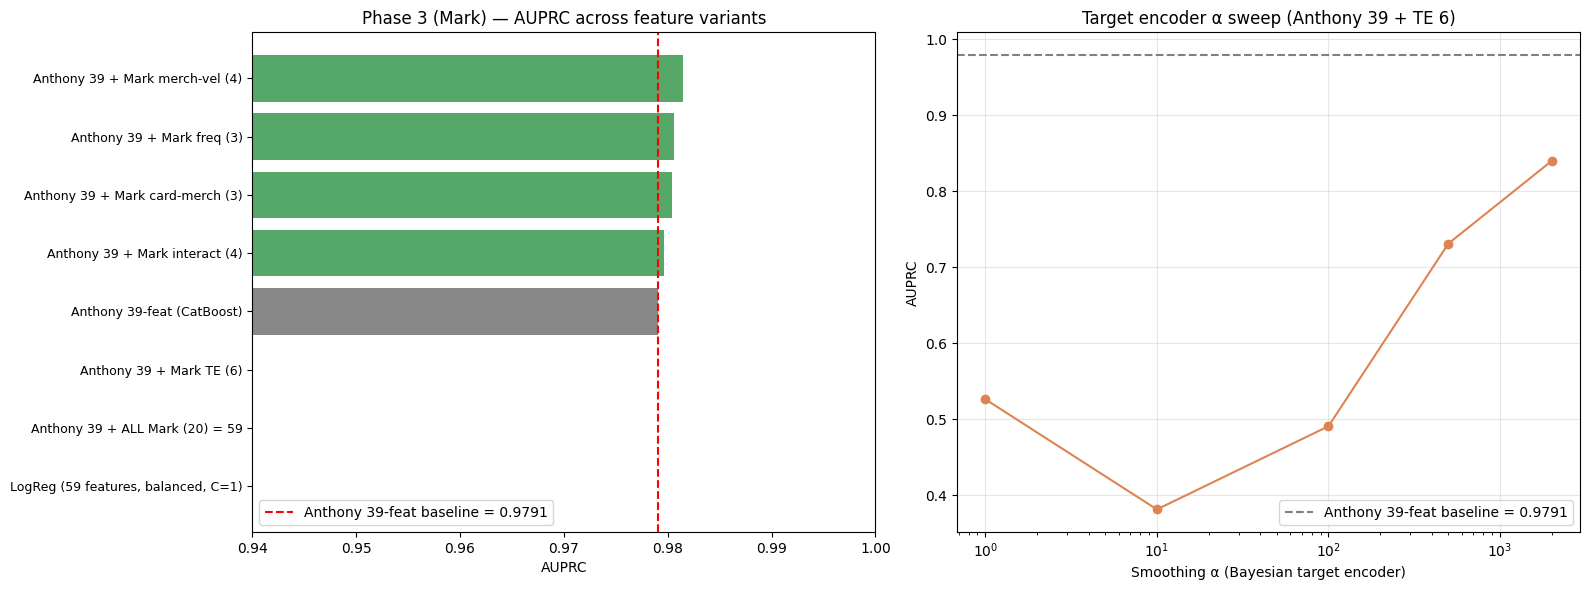

Saved C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Fraud-Detection-System\results\mark_phase3_leaderboard.png


In [15]:
# Plot 1: AUPRC comparison bar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lb = leaderboard.copy()
colors = ['#4C72B0' if 'LogReg' in lab else ('#DD8452' if 'Mark' in lab and 'ALL' in lab else
           ('#55A868' if 'Mark' in lab else '#888888')) for lab in lb['label']]
axes[0].barh(range(len(lb)), lb['auprc'].values, color=colors)
axes[0].set_yticks(range(len(lb)))
axes[0].set_yticklabels(lb['label'].values, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('AUPRC')
axes[0].set_title('Phase 3 (Mark) — AUPRC across feature variants')
axes[0].axvline(res_anthony['auprc'], ls='--', color='red',
                label=f"Anthony 39-feat baseline = {res_anthony['auprc']}")
axes[0].set_xlim(0.94, 1.0)
axes[0].legend()

# Plot 2: alpha sweep
ax2 = axes[1]
ax2.plot(alpha_df['alpha'], alpha_df['auprc'], marker='o', color='#DD8452')
ax2.set_xscale('log')
ax2.set_xlabel('Smoothing α (Bayesian target encoder)')
ax2.set_ylabel('AUPRC')
ax2.set_title('Target encoder α sweep (Anthony 39 + TE 6)')
ax2.grid(True, alpha=0.3)
ax2.axhline(res_anthony['auprc'], ls='--', color='gray',
            label=f"Anthony 39-feat baseline = {res_anthony['auprc']}")
ax2.legend()

plt.tight_layout()
out = RESULTS_DIR / 'mark_phase3_leaderboard.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')


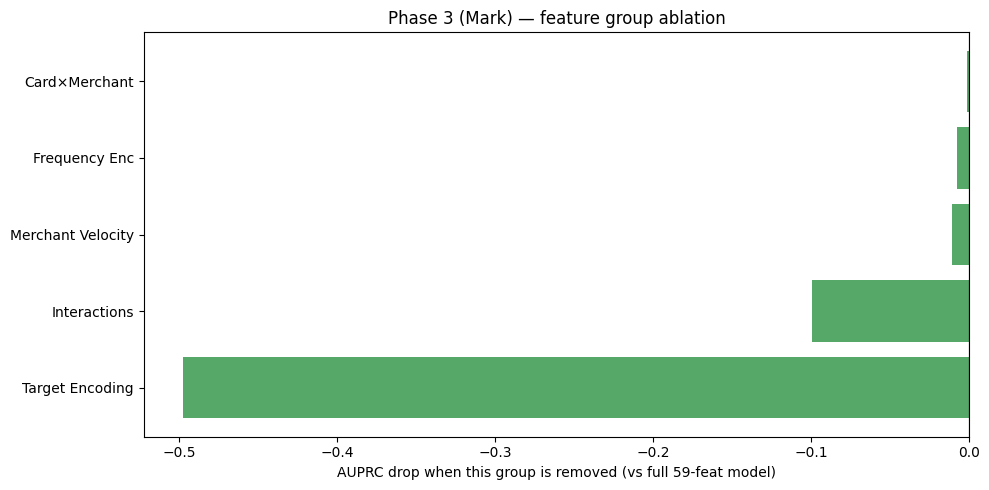

Saved C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Fraud-Detection-System\results\mark_phase3_ablation.png


In [16]:
# Plot 3: Mark-only ablation
fig, ax = plt.subplots(figsize=(10, 5))
abl_plot = abl_df[abl_df['Group Removed'] != 'ALL Mark features'].sort_values('AUPRC Drop')
ax.barh(abl_plot['Group Removed'], abl_plot['AUPRC Drop'], color='#55A868')
ax.set_xlabel('AUPRC drop when this group is removed (vs full 59-feat model)')
ax.set_title("Phase 3 (Mark) — feature group ablation")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
out = RESULTS_DIR / 'mark_phase3_ablation.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')


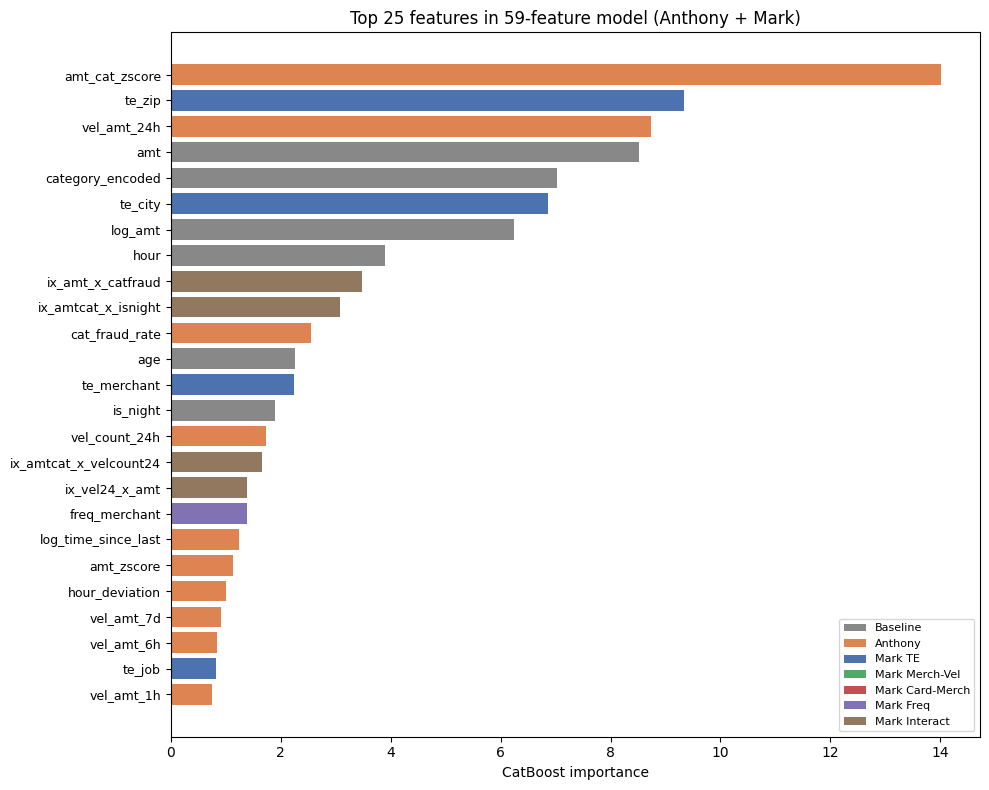

Saved C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Fraud-Detection-System\results\mark_phase3_feature_importance.png


In [17]:
# Plot 4: importance of Mark features within the 59-feat champion
fig, ax = plt.subplots(figsize=(10, 8))
imp_top = imp_m6.head(25).copy()
def grp(f):
    if f in BASELINE_FEATURES: return 'Baseline'
    if f in (ANTHONY_NEW_FEATURES): return 'Anthony'
    if f in TE_FEATURES: return 'Mark TE'
    if f in MERCHANT_VEL_FEATURES: return 'Mark Merch-Vel'
    if f in CARD_MERCHANT_FEATURES: return 'Mark Card-Merch'
    if f in FREQ_FEATURES: return 'Mark Freq'
    if f in INTERACTION_FEATURES: return 'Mark Interact'
    return 'Other'
imp_top['group'] = imp_top['feature'].map(grp)
color_map = {'Baseline':'#888888','Anthony':'#DD8452','Mark TE':'#4C72B0',
             'Mark Merch-Vel':'#55A868','Mark Card-Merch':'#C44E52',
             'Mark Freq':'#8172B3','Mark Interact':'#937860'}
ax.barh(range(len(imp_top)), imp_top['importance'].values,
        color=[color_map.get(g,'gray') for g in imp_top['group']])
ax.set_yticks(range(len(imp_top)))
ax.set_yticklabels(imp_top['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('CatBoost importance')
ax.set_title('Top 25 features in 59-feature model (Anthony + Mark)')
# legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=g) for g, c in color_map.items()]
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout()
out = RESULTS_DIR / 'mark_phase3_feature_importance.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')


In [18]:
# Persist Mark Phase 3 metrics
metrics_path = RESULTS_DIR / 'metrics.json'
metrics = json.loads(metrics_path.read_text())
metrics['mark_phase3'] = {
    'phase': 3,
    'date': '2026-04-29',
    'researcher': 'Mark Rodrigues',
    'primary_metric': 'AUPRC',
    'building_on': 'anthony_phase3 (CatBoost 39-feat AUPRC=0.9824)',
    'feature_groups': {
        'target_encoding': TE_FEATURES,
        'merchant_velocity': MERCHANT_VEL_FEATURES,
        'card_merchant': CARD_MERCHANT_FEATURES,
        'frequency_encoding': FREQ_FEATURES,
        'interactions': INTERACTION_FEATURES,
    },
    'leaderboard': leaderboard.drop(columns=['rank']).to_dict('records'),
    'alpha_sweep': alpha_df.to_dict('records'),
    'ablation': ablation,
    'top10_feature_importance': imp_m6.head(10).to_dict('records'),
}
metrics_path.write_text(json.dumps(metrics, indent=2, default=str))
print(f'Updated {metrics_path}')


Updated C:\Users\antho\OneDrive\Desktop\YC-Portfolio-Projects\Fraud-Detection-System\results\metrics.json


## Conclusions (Phase 3 — Mark)

This cell is filled in after the experiments execute (see `reports/day3_phase3_mark_report.md` for the full write-up). Key questions answered:

1. Does Bayesian target encoding lift AUPRC beyond Anthony's 0.9824?
2. Does merchant-side velocity catch fraud Anthony's card-side velocity misses?
3. Does the card×merchant repeat signal help or duplicate `is_new_merchant`?
4. With 59 features, does CatBoost still beat LogReg, or has the bottleneck shifted to features entirely?
5. Which Mark group contributes the most ablation drop?
